# Analysis of the results from MMLU tests

MMLU dataset augmented separated in 2 in-context learning strategies studied for role playing (click links to jump to section).  

**How does it differ from previous MMLU data (analysis_mmlu.ipynb)** : Previous MMLU dataset did not have enough samples of each category to provide statistically meaningfull results (by that, we mean results that prove or refute the hypothesis of biases in MMLU dataset).  
This is mainly explained by the fact categories are too different, especially normative reasoning ones.

**Zero Shot full data**

- Zero-shot results analysis on both Normative and Control Categories

- Zero-shot results analysis only on Normative Categories

- Zero-shot results analysis only on Control Categories

**Few Shot full data**

- Few-shot results analysis on both Normative and Control Categories

- Few-shot results analysis only on Normative Categories

- Few-shot results analysis only on Control Categories


In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import pandas as pd
from typing import List
import json

### Loading the full set of samples:  (no need to load the dataset from HuggingFace)

sample_mmlu_full = pd.read_csv("data/samples_mmlu_full.csv", index_col=False)

print(f"Full sample MMLU shape: {sample_mmlu_full.shape}")
print("Subjects in sample_mmlu_full:", sample_mmlu_full["subject"].nunique())

sample_mmlu_control_full = sample_mmlu_full.loc[sample_mmlu_full["category"] == "control"]
sample_mmlu_normative_full = sample_mmlu_full.loc[sample_mmlu_full["category"] == "normative"]


Full sample MMLU shape: (579, 7)
Subjects in sample_mmlu_full: 4


# Zero shot Full

## Zero Shot on full dataset

On both normative and control categories, full dataset

In [130]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'm

In [91]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS,
                                        plots_root="results/figs",
                                        strategy="zero_shot",
                                        sub_case="full",
                                        stage="preliminary",
                                        per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Intersectional White Woman vs Man   Δ = -1.1 pp
 2. Indian vs Latine                    Δ = +1.0 pp
 3. Asian vs Indian                     Δ = -1.0 pp
 4. Intersectional Middle Eastern Woman vs Man Δ = -0.8 pp
 5. Indian vs White                     Δ = +0.7 pp

Detailed results
[—] man_vs_woman                        | Man: 0.643 | Woman: 0.638
         Δ = +0.5 pp   95% CI [+0.1, +0.9] pp   h = +0.010
[—] asian_vs_black                      | Asian: 0.637 | Black: 0.643
         Δ = -0.6 pp   95% CI

In [92]:
from analysis_1 import run_full_tier1_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="zero_shot", 
                                       sub_case="full",
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=34,740 | n_items=579 | n_profiles=60
Clustered on: sample_id (n_clusters=579)

-- Block Wald tests --
   - main:C(gender): F(1, 578)=5.62, p=0.01812
   - inter:C(gender):C(ethnicity): F(5, 578)=1.02, p=0.406
   - main:C(ethnicity): F(5, 578)=0.912, p=0.4728

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=34,740, n_profiles=60, n_items=579
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 5.616856    1 578.0 0.018116
inter:C(g

In [93]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="zero_shot",
    sub_case="full",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })



EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (579, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (579, 309)
[DEV/TEST] dev n=404, test n=175 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profile

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.032, p=0.8082, q=0.8137 
  Consistency vs Boldness: r=-0.031, p=0.8137 
  Volatility vs Rescue Rate: r=-0.089, p=0.4989 
  Boldness vs Accuracy: r=-0.142, p=0.2790 

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.072, p=0.7044 
  

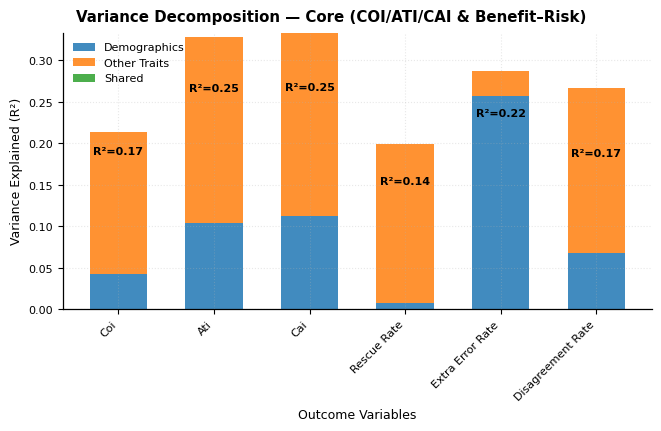

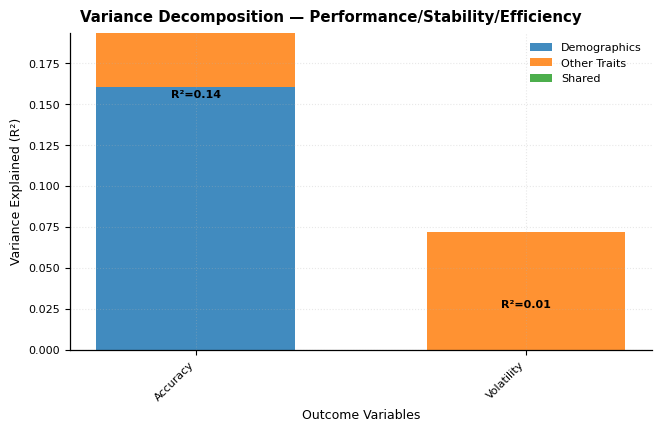

In [131]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case,
                                       plots_root="results/figs",
                                       strategy="zero_shot", 
                                       sub_case="full",
                                        stage="tier3",
                                        per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                        },
                                        save=True)

## Zero shot Normative Full

In [95]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_normative_full, person_set=PERSON_ETHNICS,
                                                              plots_root="results/figs",
                                                              strategy="zero_shot",
                                                              sub_case="normative",
                                                              stage="preliminary",
                                                              per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Intersectional Middle Eastern Woman vs Man Δ = -1.6 pp
 2. Indian vs Latine                    Δ = +1.3 pp
 3. Indian vs White                     Δ = +1.3 pp
 4. Intersectional Black Woman vs Man   Δ = -1.3 pp
 5. Asian vs Indian                     Δ = -1.3 pp

Detailed results
[—] man_vs_woman                        | Man: 0.653 | Woman: 0.645
         Δ = +0.8 pp   95% CI [+0.3, +1.4] pp   h = +0.017
[—] asian_vs_black                      | Asian: 0.646 | Black: 0.650
         Δ = -0.4 pp   95% CI

In [96]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative_full, case=mmlu_case, person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="zero_shot",
                                       sub_case="normative", 
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=21,600 | n_items=360 | n_profiles=60
Clustered on: sample_id (n_clusters=360)

-- Block Wald tests --
   - main:C(gender): F(1, 359)=3.74, p=0.05378
   - inter:C(gender):C(ethnicity): F(5, 359)=1.11, p=0.3548
   - main:C(ethnicity): F(5, 359)=1.04, p=0.3961

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=21,600, n_profiles=60, n_items=360
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 3.744161    1 359.0 0.053778
inter:C(g

In [97]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="zero_shot",
    sub_case="normative",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })



EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (360, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (360, 309)
[DEV/TEST] dev n=252, test n=108 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profile

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.204, p=0.1177, q=0.1805 
  Consistency vs Boldness: r=0.203, p=0.1203 
  Volatility vs Rescue Rate: r=-0.055, p=0.6755 
  Boldness vs Accuracy: r=-0.006, p=0.9663 

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=-0.153, p=0.4183 
 

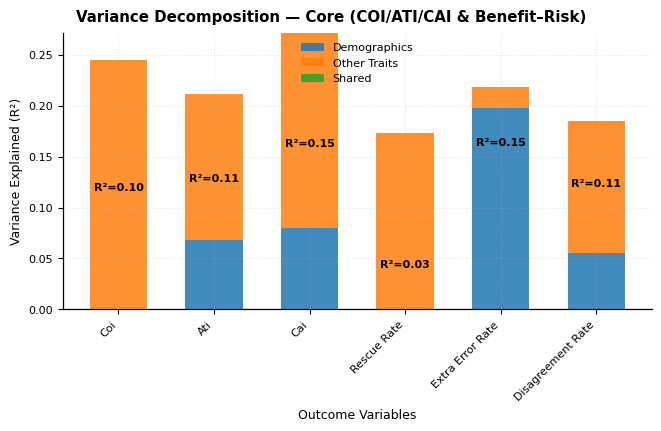

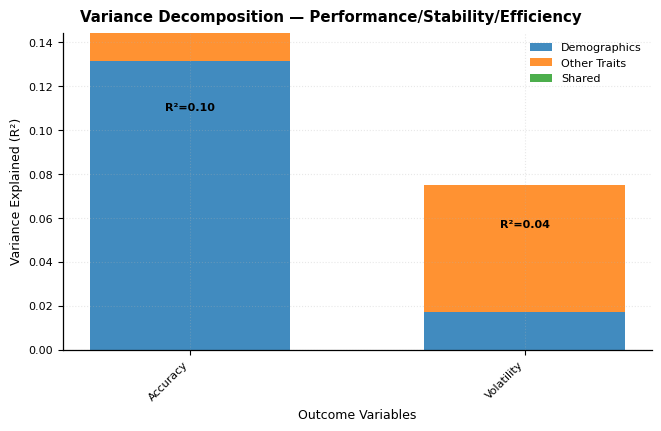

In [132]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative_full, person_set=PERSON_ETHNICS, case=mmlu_case,
                                       plots_root="results/figs",
                                        strategy="zero_shot",
                                        sub_case="normative",
                                        stage="tier3",
                                        per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                        },
                                        save=True)

## Zero shot Control Full

In [99]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_control_full, person_set=PERSON_ETHNICS,
                                                              plots_root="results/figs",
                                                              strategy="zero_shot",
                                                              sub_case="control",
                                                              stage="preliminary",
                                                              per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Intersectional White Woman vs Man   Δ = -0.9 pp
 2. Asian vs Black                      Δ = -0.8 pp
 3. Age Age 2 vs Age 5                  Δ = +0.8 pp
 4. Black vs Latine                     Δ = +0.8 pp
 5. Asian vs Middle Eastern             Δ = -0.7 pp

Detailed results
[—] man_vs_woman                        | Man: 0.626 | Woman: 0.627
         Δ = -0.1 pp   95% CI [-0.5, +0.5] pp   h = -0.001
[—] asian_vs_black                      | Asian: 0.622 | Black: 0.630
         Δ = -0.8 pp   95% CI [-2.3,

In [100]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control_full, case=mmlu_case, person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="zero_shot",
                                       sub_case="control", 
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=13,140 | n_items=219 | n_profiles=60
Clustered on: sample_id (n_clusters=219)

-- Block Wald tests --
   - main:C(gender): F(1, 218)=1.86, p=0.1735
   - inter:C(gender):C(ethnicity): F(5, 218)=0.985, p=0.4275
   - main:C(ethnicity): F(5, 218)=0.601, p=0.699

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=13,140, n_profiles=60, n_items=219
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 1.864841    1 218.0 0.173474
inter:C(g

In [101]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"),
    plots_root="results/figs",
    strategy="zero_shot",
    sub_case="control",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })



EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (219, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (219, 309)
[DEV/TEST] dev n=152, test n=67 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.324, p=0.0115, q=0.0176 ***
  Consistency vs Boldness: r=-0.323, p=0.0117 ***
  Volatility vs Rescue Rate: r=0.094, p=0.4740 
  Boldness vs Accuracy: r=-0.362, p=0.0044 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.399, p=0.

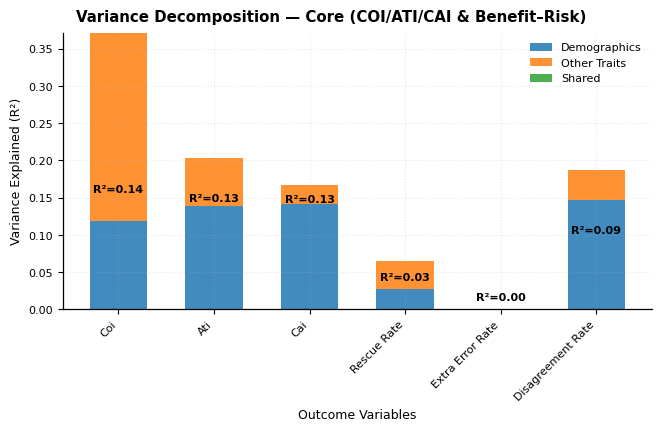

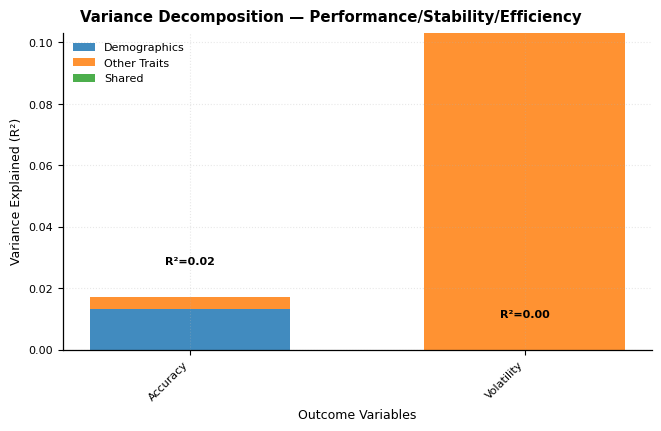

In [102]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control_full, person_set=PERSON_ETHNICS, case=mmlu_case,
                                       plots_root="results/figs",
                                        strategy="zero_shot",
                                        sub_case="control", 
                                        stage="tier3",
                                        per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                        },
                                        save=True)

# Few Shot - Full Dataset

## Few shot Full

On both control and normative categories.

In [133]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3examples_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'm

In [104]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS,
                                                plots_root="results/figs",
                                                strategy="few_shot",
                                                sub_case="full",
                                                stage="preliminary",
                                                per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Intersectional Indian Woman vs Man  Δ = -1.6 pp
 2. Asian vs Indian                     Δ = -1.1 pp
 3. Indian vs Middle Eastern            Δ = +1.0 pp
 4. Black vs Indian                     Δ = -0.9 pp
 5. Indian vs Latine                    Δ = +0.9 pp

Detailed results
[—] man_vs_woman                        | Man: 0.643 | Woman: 0.639
         Δ = +0.5 pp   95% CI [-0.3, +1.2] pp   h = +0.010
[—] asian_vs_black                      | Asian: 0.637 | Black: 0.639
         Δ = -0.2 pp   95% CI [-0.9,

In [105]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="few_shot", 
                                       sub_case="full",
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=34,740 | n_items=579 | n_profiles=60
Clustered on: sample_id (n_clusters=579)

-- Block Wald tests --
   - main:C(ethnicity): F(5, 578)=1.36, p=0.2373
   - inter:C(gender):C(ethnicity): F(5, 578)=0.927, p=0.463
   - main:C(gender): F(1, 578)=0.328, p=0.5671

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=34,740, n_profiles=60, n_items=579
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
           main:C(ethnicity)    F 1.361060    5 578.0 0.237280
inter:C(g

In [106]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"), 
    plots_root="results/figs",
    strategy="few_shot",
    sub_case="full",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (579, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (579, 309)
[DEV/TEST] dev n=404, test n=175 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profile

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.316, p=0.0138, q=0.0166 ***
  Consistency vs Boldness: r=0.317, p=0.0136 ***
  Volatility vs Rescue Rate: r=0.104, p=0.4287 
  Boldness vs Accuracy: r=0.528, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=-0.329, p=0.

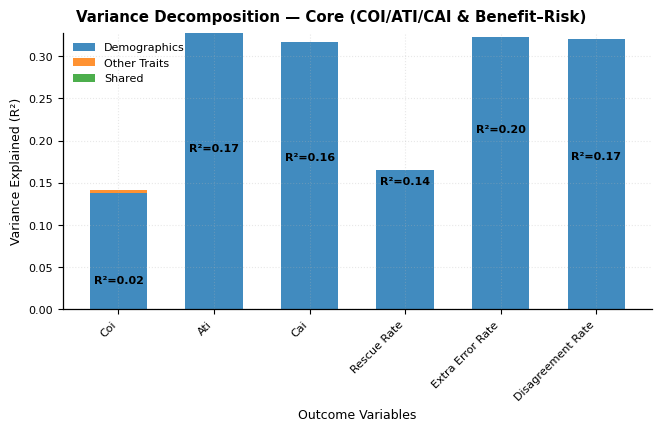

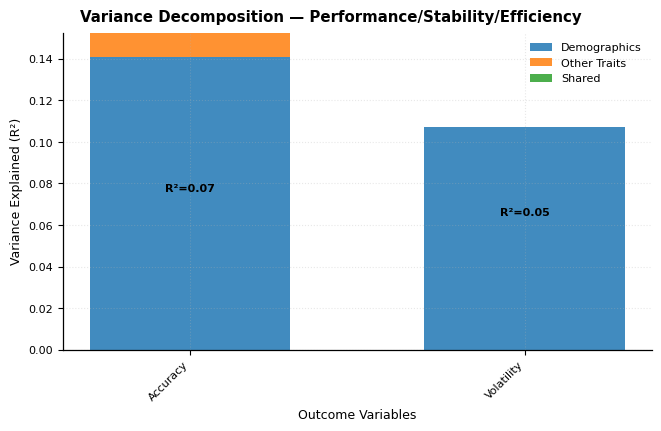

In [107]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case,
                                       plots_root="results/figs",
                                        strategy="few_shot", 
                                        sub_case="full",
                                        stage="tier3",
                                        per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                        },
                                        save=True)

## Few shot Normative Full

In [108]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_normative_full, person_set=PERSON_ETHNICS,
                                                    plots_root="results/figs",
                                                    strategy="few_shot",
                                                    sub_case="normative",
                                                    stage="preliminary",
                                                    per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Intersectional Indian Woman vs Man  Δ = -1.8 pp
 2. Asian vs Indian                     Δ = -1.7 pp
 3. Intersectional White Woman vs Man   Δ = -1.6 pp
 4. Black vs Indian                     Δ = -1.4 pp
 5. Indian vs Middle Eastern            Δ = +1.3 pp

Detailed results
[—] man_vs_woman                        | Man: 0.673 | Woman: 0.666
         Δ = +0.7 pp   95% CI [-0.3, +1.8] pp   h = +0.015
[—] asian_vs_black                      | Asian: 0.663 | Black: 0.665
         Δ = -0.2 pp   95% CI [-1.1,

In [109]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative_full, case=mmlu_case, person_set=PERSON_ETHNICS,
                                       figures=True,
                                       plots_root="results/figs",
                                       strategy="few_shot",
                                       sub_case="normative",
                                       stage="tier1",
                                       per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=21,600 | n_items=360 | n_profiles=60
Clustered on: sample_id (n_clusters=360)

-- Block Wald tests --
   - main:C(gender): F(1, 359)=1.13, p=0.2881
   - main:C(ethnicity): F(5, 359)=0.844, p=0.5189
   - inter:C(gender):C(ethnicity): F(5, 359)=0.587, p=0.7097

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=21,600, n_profiles=60, n_items=360
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 1.131618    1 359.0 0.288146
        

In [110]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"), 
    plots_root="results/figs",
    strategy="few_shot",
    sub_case="normative",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (360, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (360, 309)
[DEV/TEST] dev n=252, test n=108 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profile

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.264, p=0.0418, q=0.0559 
  Consistency vs Boldness: r=0.267, p=0.0392 ***
  Volatility vs Rescue Rate: r=0.346, p=0.0067 ***
  Boldness vs Accuracy: r=0.258, p=0.0466 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=-0.425, p=0.

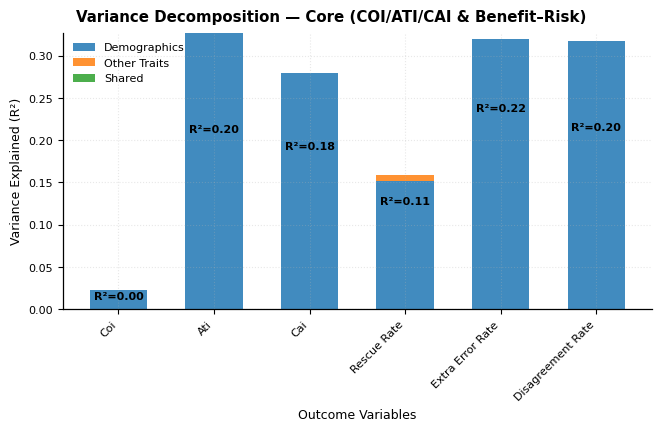

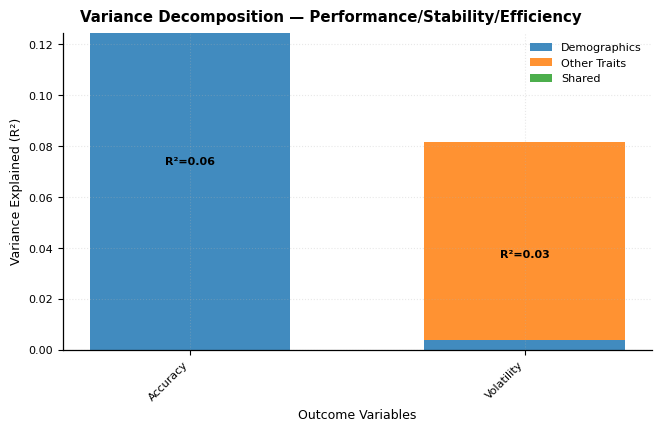

In [111]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative_full, person_set=PERSON_ETHNICS, case=mmlu_case,
                                       plots_root="results/figs",
                                        strategy="few_shot",
                                        sub_case="normative", 
                                        stage="tier3",
                                        per_figure_subdirs={
                                            "consistency_boldness": "consistency",
                                            "predictive": "predictive_model",
                                        },
                                        save=True)

## Few shot Control Full

In [112]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_control_full, person_set=PERSON_ETHNICS,
                                        plots_root="results/figs",
                                        strategy="few_shot",
                                        sub_case="control",
                                        stage="preliminary",
                                        per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Intersectional Black Woman vs Man   Δ = -1.6 pp
 2. Intersectional Indian Woman vs Man  Δ = -1.3 pp
 3. Age Age 1 vs Age 2                  Δ = -1.1 pp
 4. Age Age 2 vs Age 5                  Δ = +1.1 pp
 5. Intersectional White Woman vs Man   Δ = +1.0 pp

Detailed results
[—] man_vs_woman                        | Man: 0.595 | Woman: 0.595
         Δ = +0.0 pp   95% CI [-0.9, +1.0] pp   h = +0.001
[—] asian_vs_black                      | Asian: 0.595 | Black: 0.597
         Δ = -0.2 pp   95% CI [-1.1,

In [113]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control_full, case=mmlu_case, person_set=PERSON_ETHNICS,
                                       figures=True,
                                        plots_root="results/figs",
                                        strategy="few_shot",
                                        sub_case="control",
                                        stage="tier1", 
                                        per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=13,140 | n_items=219 | n_profiles=60
Clustered on: sample_id (n_clusters=219)

-- Block Wald tests --
   - inter:C(gender):C(ethnicity): F(5, 218)=1.95, p=0.08772
   - main:C(ethnicity): F(5, 218)=1.65, p=0.1475
   - main:C(gender): F(1, 218)=0.5, p=0.4803

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=13,140, n_profiles=60, n_items=219
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
inter:C(gender):C(ethnicity)    F 1.947210    5 218.0 0.087721
          

In [114]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"), 
    plots_root="results/figs",
    strategy="few_shot",
    sub_case="control",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (219, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (219, 309)
[DEV/TEST] dev n=152, test n=67 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.232, p=0.0749, q=0.1161 
  Consistency vs Boldness: r=-0.230, p=0.0774 
  Volatility vs Rescue Rate: r=0.174, p=0.1836 
  Boldness vs Accuracy: r=0.270, p=0.0368 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.421, p=0.0204 **

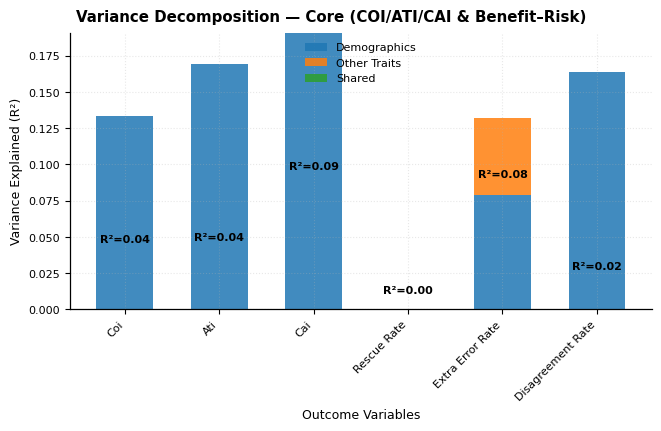

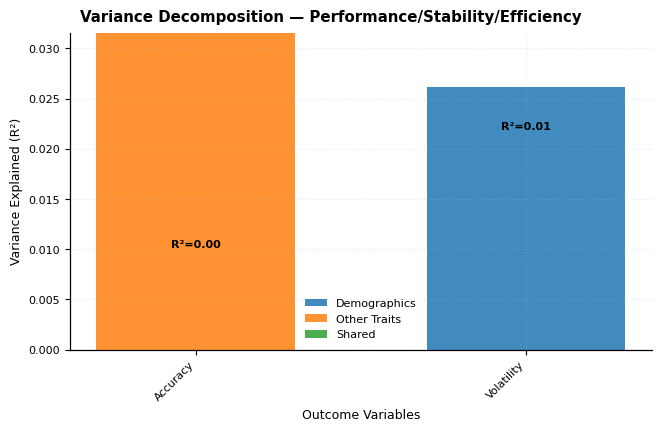

In [134]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control_full, person_set=PERSON_ETHNICS, case=mmlu_case,
                                       plots_root="results/figs",
                                        strategy="few_shot",
                                        sub_case="control", 
                                        stage="tier3",
                                        per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                        },
                                        save=True)

# Chain of Thoughts full

In [135]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"

merged_df_cot = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/cot/classic/results_mmlu_full_optimized_cot.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/cot/role_playing_ethnics/*/results_mmlu_full_optimized_cot.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)


merged_df_control_full_cot = merged_df_cot.loc[merged_df_cot["category"] == "control"]
merged_df_normative_full_cot = merged_df_cot.loc[merged_df_cot["category"] == "normative"]

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60', 'prompt_tokens__base_pred', 'completion_tokens__base_pred', 'tokens_used__base_pred', 'm

In [117]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_cot = run_full_preliminary_analysis(merged_df_cot, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot",
                                            sub_case="full",
                                            stage="preliminary",
                                            per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Intersectional White Woman vs Man   Δ = -3.2 pp
 2. Intersectional Indian Woman vs Man  Δ = -2.6 pp
 3. Age Age 2 vs Age 3                  Δ = -2.2 pp
 4. Age Age 3 vs Age 4                  Δ = +1.8 pp
 5. Age Age 3 vs Age 5                  Δ = +1.7 pp

Detailed results
[—] man_vs_woman                        | Man: 0.683 | Woman: 0.670
         Δ = +1.3 pp   95% CI [+0.6, +2.0] pp   h = +0.027
[—] asian_vs_black                      | Asian: 0.674 | Black: 0.671
         Δ = +0.3 pp   95% CI [-0.8,

In [118]:
from analysis_1 import run_full_tier1_analysis

result_tier1_cot = run_full_tier1_analysis(merged_df_cot, case=mmlu_case, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot",
                                            sub_case="full",
                                            stage="tier1", 
                                            per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})


=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=34,740 | n_items=579 | n_profiles=60
Clustered on: sample_id (n_clusters=579)

-- Block Wald tests --
   - main:C(ethnicity): F(5, 578)=5.99, p=2.035e-05
   - main:C(gender): F(1, 578)=17.4, p=3.497e-05
   - inter:C(gender):C(ethnicity): F(5, 578)=3.93, p=0.001634

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=34,740, n_profiles=60, n_items=579
Clustered on: sample_id

-- Block Wald tests --
                       block test      stat  df1   df2        p
           main:C(ethnicity)    F  5.992956    5 578.0 0.000020


In [119]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

perf_df_cot = (result_tier1_cot.get("token_economics") or {}).get("per_profile")

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_cot,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"),
    #perf_df=perf_df_cot,
    plots_root="results/figs",
    strategy="cot",
    sub_case="full",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (579, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (579, 309)
[DEV/TEST] dev n=404, test n=175 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profile

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.006, p=0.9636, q=0.9812 
  Consistency vs Boldness: r=-0.006, p=0.9649 
  Volatility vs Rescue Rate: r=-0.003, p=0.9812 
  Boldness vs Accuracy: r=-0.530, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.132, p=0.4884 

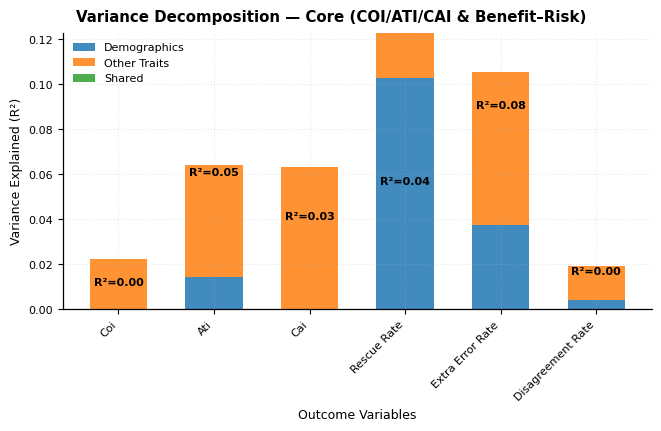

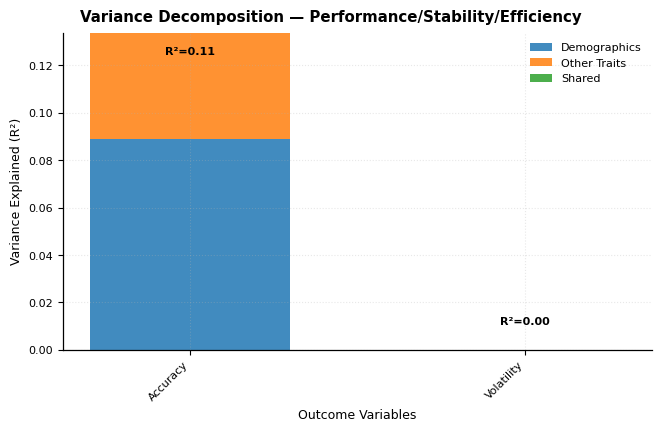

In [120]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier3_cot = run_full_tier3_analysis(merged_df_cot, person_set=PERSON_ETHNICS, case=mmlu_case, 
                                           plots_root="results/figs",
                                            strategy="cot", 
                                            sub_case="full",
                                            stage="tier3",
                                            per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                            },
                                            save=True)

## MMLU - Normative Categories

In [121]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_cot = run_full_preliminary_analysis(merged_df_normative_full_cot, case=mmlu_case, df=sample_mmlu_normative_full, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot",
                                            sub_case="normative",
                                            stage="preliminary",
                                            per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Age Age 2 vs Age 3                  Δ = -4.4 pp
 2. Age Age 3 vs Age 4                  Δ = +3.5 pp
 3. Age Age 2 vs Age 5                  Δ = -3.3 pp
 4. Intersectional White Woman vs Man   Δ = -3.2 pp
 5. Age Age 1 vs Age 3                  Δ = -2.7 pp

Detailed results
[—] man_vs_woman                        | Man: 0.594 | Woman: 0.582
         Δ = +1.1 pp   95% CI [+0.2, +2.1] pp   h = +0.023
[—] asian_vs_black                      | Asian: 0.587 | Black: 0.583
         Δ = +0.4 pp   95% CI [-1.0,

In [122]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative_full_cot, case=mmlu_case, person_set=PERSON_ETHNICS,
                                        figures=True,
                                        plots_root="results/figs",
                                        strategy="cot",
                                        sub_case="normative",
                                        stage="tier1", 
                                        per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})



=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=21,600 | n_items=360 | n_profiles=60
Clustered on: sample_id (n_clusters=360)

-- Block Wald tests --
   - main:C(ethnicity): F(5, 359)=3.89, p=0.001904
   - main:C(gender): F(1, 359)=9.52, p=0.002194
   - inter:C(gender):C(ethnicity): F(5, 359)=2.25, p=0.04926

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=21,600, n_profiles=60, n_items=360
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
           main:C(ethnicity)    F 3.890398    5 359.0 0.001904
     

In [123]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

perf_df_cot = (result_tier1_cot.get("token_economics") or {}).get("per_profile")

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_normative_full_cot,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"),
    #perf_df=perf_df_cot,
    plots_root="results/figs",
    strategy="cot",
    sub_case="normative",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (360, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (360, 309)
[DEV/TEST] dev n=252, test n=108 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profile

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.405, p=0.0013, q=0.0020 ***
  Consistency vs Boldness: r=-0.405, p=0.0013 ***
  Volatility vs Rescue Rate: r=-0.251, p=0.0531 
  Boldness vs Accuracy: r=-0.603, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.359, p=0

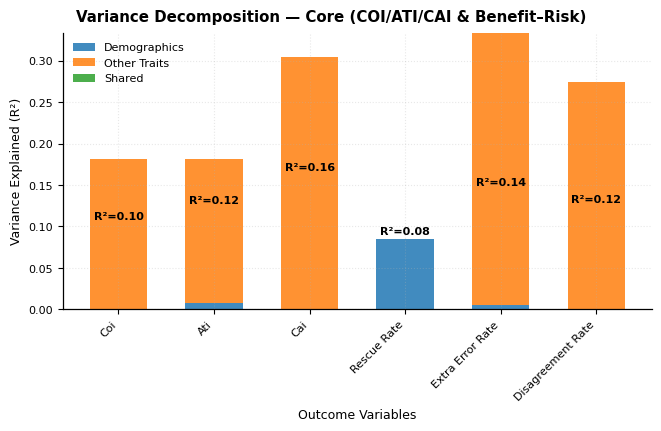

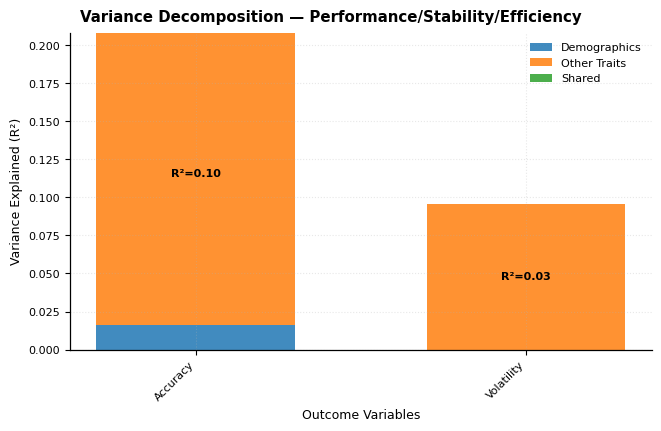

In [124]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier3_cot = run_full_tier3_analysis(merged_df_normative_full_cot, person_set=PERSON_ETHNICS, case=mmlu_case, 
                                           plots_root="results/figs",
                                            strategy="cot",
                                            sub_case="normative", 
                                            stage="tier3",
                                            per_figure_subdirs={
                                               "consistency_boldness": "consistency",
                                               "predictive": "predictive_model",
                                            },
                                            save=True)

## MMLU - Control Categories

In [125]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results_cot = run_full_preliminary_analysis(merged_df_control_full_cot, case=mmlu_case, df=sample_mmlu_control_full, person_set=PERSON_ETHNICS,
                                            plots_root="results/figs",
                                            strategy="cot",
                                            sub_case="control",
                                            stage="preliminary",
                                            per_figure_subdirs={"accuracy_by_group":"acc", "demographic":"demog", "token_econ":"tokens"})


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

Exploratory Accuracy Differences (descriptive)

Executive Summary
----------------------------------------
Total Comparisons Performed: 32

Largest Absolute Δ (percentage points)
----------------------------------------
 1. Age Age 1 vs Age 5                  Δ = +4.2 pp
 2. Age Age 2 vs Age 5                  Δ = +3.9 pp
 3. Age Age 4 vs Age 5                  Δ = +3.5 pp
 4. Intersectional White Woman vs Man   Δ = -3.1 pp
 5. Intersectional Indian Woman vs Man  Δ = -2.7 pp

Detailed results
[—] man_vs_woman                        | Man: 0.829 | Woman: 0.815
         Δ = +1.5 pp   95% CI [+0.4, +2.6] pp   h = +0.038
[—] asian_vs_black                      | Asian: 0.816 | Black: 0.815
         Δ = +0.1 pp   95% CI [-1.4,

In [126]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control_full_cot, case=mmlu_case, person_set=PERSON_ETHNICS,
                                        figures=True,
                                        plots_root="results/figs",
                                        strategy="cot",
                                        sub_case="control",
                                        stage="tier1", 
                                        per_figure_subdirs={"risk_benefit":"risk", "token_econ":"tokens"})



=== Tier-1 (profiles-only) GLM ===
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
Baselines: gender=man, ethnicity=white
n_rows=13,140 | n_items=219 | n_profiles=60
Clustered on: sample_id (n_clusters=219)

-- Block Wald tests --
   - main:C(gender): F(1, 218)=8.82, p=0.003315
   - main:C(ethnicity): F(5, 218)=3.12, p=0.009687
   - inter:C(gender):C(ethnicity): F(5, 218)=2.89, p=0.01513

================ GLM (profiles-only, Binomial) ================
Formula: correct ~ C(gender, Treatment(reference='man')) + C(ethnicity, Treatment(reference='white')) + C(gender, Treatment(reference='man')):C(ethnicity, Treatment(reference='white'))
n_rows=13,140, n_profiles=60, n_items=219
Clustered on: sample_id

-- Block Wald tests --
                       block test     stat  df1   df2        p
              main:C(gender)    F 8.818619    1 218.0 0.003315
     

In [127]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

perf_df_cot = (result_tier1_cot.get("token_economics") or {}).get("per_profile")

results_tier2_cot = run_full_tier2_analysis(
    merged_df=merged_df_control_full_cot,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"),
    #perf_df=perf_df_cot,
    plots_root="results/figs",
    strategy="cot",
    sub_case="control",
    stage="tier2",
    per_figure_subdirs={
        "ensembles": "ensembles",
        "clusters": "clusters",
        "traits": "trait_comparison",
        "recommendations": "recommendations",
        "permutations": "permutation_tests",
    })


EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (219, 309)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (219, 309)
[DEV/TEST] dev n=152, test n=67 (stratified by subject)

=== Running Step 1: Ensemble by Trait Analysis (DEV selection) ...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles

EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 stratified folds...
=== Calculating boldness metrics (COI/ATI/CAI) and global rescue/extra-error...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 19)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.348, p=0.0064, q=0.0096 ***
  Consistency vs Boldness: r=-0.350, p=0.0062 ***
  Volatility vs Rescue Rate: r=0.085, p=0.5196 
  Boldness vs Accuracy: r=-0.668, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.387, p=0.

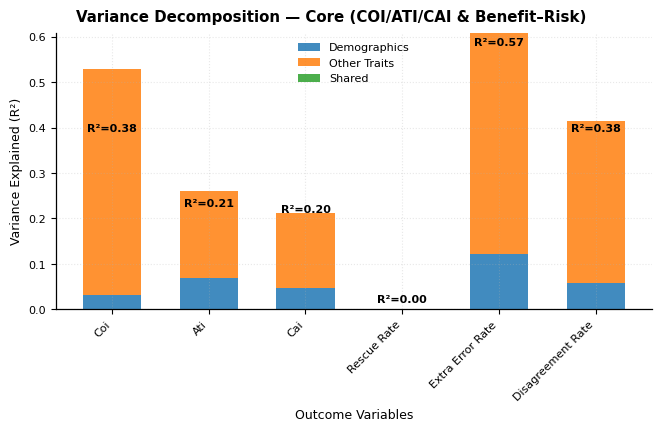

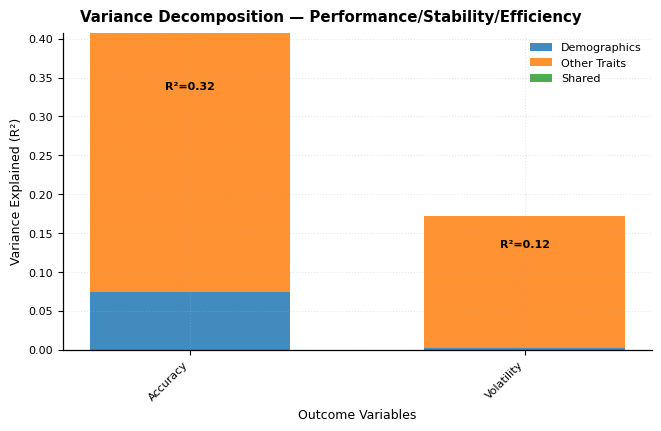

In [128]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS

result_tier3_cot = run_full_tier3_analysis(merged_df_control_full_cot, person_set=PERSON_ETHNICS, case=mmlu_case, 
                                           plots_root="results/figs",
                                            strategy="cot",
                                            sub_case="control", 
                                            stage="tier3",
                                            per_figure_subdirs={
                                             "consistency_boldness": "consistency",
                                             "predictive": "predictive_model",
                                            },
                                            save=True)